# PINN pro 2D lineární elastostatiku

Cílem je aproximovat vektorové posunutí $\mathbf u=(u_1,u_2)$ na oblasti

$$
\Omega=(-1,1)^2.
$$

Přesné řešení je

$$
\mathbf u(x,y)
=
a
\begin{bmatrix}
x^2-y^2\\
2xy
\end{bmatrix},
\qquad a=0.05.
$$

Materiálové parametry jsou

$$
E=1,\qquad
\nu=\frac14,\qquad
\lambda=\mu=\frac25.
$$

## Silná forma

Tenzor malých deformací a napětí jsou

$$
\varepsilon(\mathbf u)
=
\frac12\left(\nabla\mathbf u+\nabla\mathbf u^\mathsf T\right),
$$

$$
\sigma(\mathbf u)
=
\lambda\,\operatorname{tr}(\varepsilon)I+2\mu\varepsilon.
$$

Rovnice rovnováhy je

$$
\nabla\cdot\sigma+\mathbf b=\mathbf 0
\qquad\text{v }\Omega.
$$

Pro zadané řešení platí

$$
\nabla\mathbf u
=
\begin{bmatrix}
2ax & -2ay\\
2ay & 2ax
\end{bmatrix},
\qquad
\varepsilon
=
\begin{bmatrix}
2ax & 0\\
0 & 2ax
\end{bmatrix}.
$$

Proto

$$
\operatorname{tr}(\varepsilon)=4ax
$$

a

$$
\sigma
=
4a(\lambda+\mu)x\,I
=
0.16x\,I.
$$

Divergence napětí je

$$
\nabla\cdot\sigma
=
\begin{bmatrix}
0.16\\
0
\end{bmatrix},
$$

takže objemová síla musí být

$$
\boxed{
\mathbf b
=
\begin{bmatrix}
-0.16\\
0
\end{bmatrix}
}.
$$

## Smíšené okrajové podmínky

Na levé a pravé hraně předepisujeme Dirichletovu podmínku
$\mathbf u=\mathbf u_{\mathrm{exact}}$.

Na pravé hraně $x=1$ tedy platí

$$
\mathbf u(1,y)
=
a
\begin{bmatrix}
1-y^2\\
2y
\end{bmatrix}.
$$

Na levé hraně $x=-1$ platí

$$
\mathbf u(-1,y)
=
a
\begin{bmatrix}
1-y^2\\
-2y
\end{bmatrix}.
$$

Na horní a dolní hraně předepisujeme Neumannovu podmínku

$$
\sigma\mathbf n=\mathbf t.
$$

Protože $\sigma=0.16x\,I$, na horní hraně $y=1$ s vnější normálou
$\mathbf n=(0,1)$ dostaneme

$$
\mathbf t_{\mathrm{top}}(x)
=
(0.16xI)
\begin{bmatrix}
0\\
1
\end{bmatrix}
=
\begin{bmatrix}
0\\
0.16x
\end{bmatrix}.
$$

Na dolní hraně $y=-1$ je vnější normála $\mathbf n=(0,-1)$, takže

$$
\mathbf t_{\mathrm{bottom}}(x)
=
(0.16xI)
\begin{bmatrix}
0\\
-1
\end{bmatrix}
=
\begin{bmatrix}
0\\
-0.16x
\end{bmatrix}.
$$


## 1. Import knihoven

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


## 2. Nastavení parametrů

- `USE_DATA = True`: k fyzikální a okrajové loss se přidají známé hodnoty posunutí.
- `USE_DATA = False`: čistá PINN bez supervizovaných dat.
- Posledních 100 epoch používá L-BFGS, předchozí epochy Adam.

In [36]:
USE_DATA = False

E = 1.0
NU = 1.0 / 4.0
LAMBDA = 2.0 / 5.0
MU = 2.0 / 5.0
AMPLITUDE = 0.05

N_PDE_TRAIN = 2000
N_PDE_TEST = 2000
N_BOUNDARY_PER_EDGE = 100

N_DATA_TRAIN = 200
N_DATA_TEST = 200

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

E_FROM_LAME = MU * (3.0 * LAMBDA + 2.0 * MU) / (LAMBDA + MU)
NU_FROM_LAME = LAMBDA / (2.0 * (LAMBDA + MU))

print(f"E z Lameho konstant:  {E_FROM_LAME:.6f}")
print(f"nu z Lameho konstant: {NU_FROM_LAME:.6f}")


E z Lameho konstant:  1.000000
nu z Lameho konstant: 0.250000


## 3. Přesné řešení, napětí a objemová síla

In [37]:
def exact_solution(xy):
    """Presne vektorove posunuti [u1, u2]."""
    x = xy[:, 0:1]
    y = xy[:, 1:2]

    u1 = AMPLITUDE * (x**2 - y**2)
    u2 = 2.0 * AMPLITUDE * x * y

    return torch.cat((u1, u2), dim=1)


def body_force(xy):
    """b = -div(sigma) pro zvolene presne reseni."""
    b1 = -4.0 * AMPLITUDE * (LAMBDA + MU) * torch.ones_like(xy[:, 0:1])
    b2 = torch.zeros_like(xy[:, 1:2])

    return torch.cat((b1, b2), dim=1)


def exact_stress(xy):
    """Presne slozky sigma_xx, sigma_yy, sigma_xy."""
    x = xy[:, 0:1]

    normal_stress = 4.0 * AMPLITUDE * (LAMBDA + MU) * x
    shear_stress = torch.zeros_like(x)

    return normal_stress, normal_stress, shear_stress


def exact_traction(xy, normals):
    """Presna trakce t = sigma*n."""
    sigma_xx, sigma_yy, sigma_xy = exact_stress(xy)

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny

    return torch.cat((traction_x, traction_y), dim=1)


## 4. Neuronová síť

In [38]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 2),
        )

    def forward(self, xy):
        return self.net(xy)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Trénovací, testovací a okrajové body

- `xy_pde_train`: vnitřní kolokační body použité ve fyzikální loss.
- `xy_pde_test`: body použité pouze při závěrečném testování.
- `xy_dirichlet`: body na levé a pravé hraně se známým posunutím.
- `xy_neumann`: body na horní a dolní hraně se známou trakcí.
- Při zapnutých datech se vytvoří také oddělené supervizované train/test body.


In [39]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = -1.0 + 2.0 * torch.rand(
    N_PDE_TRAIN,
    2,
    generator=pde_train_generator,
)
xy_pde_train.requires_grad_(True)

pde_test_generator = torch.Generator().manual_seed(SEED + 2)
xy_pde_test = -1.0 + 2.0 * torch.rand(
    N_PDE_TEST,
    2,
    generator=pde_test_generator,
)
xy_pde_test.requires_grad_(True)


t = torch.linspace(-1.0, 1.0, N_BOUNDARY_PER_EDGE).view(-1, 1)


# Dirichletovy podminky vlevo a vpravo.
left = torch.cat((-torch.ones_like(t), t), dim=1)
right = torch.cat((torch.ones_like(t), t), dim=1)

xy_dirichlet = torch.cat((left, right), dim=0)
u_dirichlet = exact_solution(xy_dirichlet)


# Neumannovy podminky nahore a dole.
bottom = torch.cat((t, -torch.ones_like(t)), dim=1)
top = torch.cat((t, torch.ones_like(t)), dim=1)

normal_bottom = torch.cat(
    (torch.zeros_like(t), -torch.ones_like(t)),
    dim=1,
)
normal_top = torch.cat(
    (torch.zeros_like(t), torch.ones_like(t)),
    dim=1,
)

xy_neumann = torch.cat((bottom, top), dim=0)
normals_neumann = torch.cat((normal_bottom, normal_top), dim=0)

# Presnou trakci spocitame pred zapnutim derivovani vstupu.
traction_neumann = exact_traction(xy_neumann, normals_neumann).detach()

# Derivace posunuti jsou nutne pro vypocet sigma*n.
xy_neumann.requires_grad_(True)


if USE_DATA:
    data_train_generator = torch.Generator().manual_seed(SEED + 3)
    xy_data_train = -1.0 + 2.0 * torch.rand(
        N_DATA_TRAIN,
        2,
        generator=data_train_generator,
    )
    u_data_train = exact_solution(xy_data_train)

    data_test_generator = torch.Generator().manual_seed(SEED + 4)
    xy_data_test = -1.0 + 2.0 * torch.rand(
        N_DATA_TEST,
        2,
        generator=data_test_generator,
    )
    u_data_test = exact_solution(xy_data_test)


## 6. PDE reziduum a ztrátová funkce

Fyzikální reziduum PINN je definováno jako

$$
\mathbf{r}_{\theta}(x,y)
=
\nabla \cdot \boldsymbol{\sigma}(\mathbf{u}_{\theta})
+\mathbf{b}.
$$


PDE ztrátová funkce je:

$$
\mathcal{L}_{\mathrm{PDE}}
=
\frac{1}{2N_c}
\sum_{i=1}^{N_c}
\left\|
\mathbf{r}_{\theta}(x_i,y_i)
\right\|_2^2.
$$


Celková ztrátová funkce je

$$
\mathcal{L}
=
\mathcal{L}_{\mathrm{PDE}}
+
\mathcal{L}_{\mathrm{D}}
+
\mathcal{L}_{\mathrm{N}}
+
\mathcal{L}_{\mathrm{data}},
$$

kde
$$
\mathcal{L}_{\mathrm{D}}
=
\frac{1}{2N_D}
\sum_{i=1}^{N_D}
\left\|
\mathbf{u}_{\theta}(\mathbf{x}_i)
-
\mathbf{u}_{D}(\mathbf{x}_i)
\right\|_2^2
$$

a

$$
\mathcal{L}_{\mathrm{N}}
=
\frac{1}{2N_N}
\sum_{i=1}^{N_N}
\left\|
\boldsymbol{\sigma}
\left(\mathbf{u}_{\theta}(\mathbf{x}_i)\right)
\mathbf{n}_i
-
\mathbf{t}(\mathbf{x}_i)
\right\|_2^2.
$$

Pro `USE_DATA = False` platí

$$
\mathcal{L}_{\mathrm{data}}=0.
$$


In [40]:
def stress_components(xy):
    """Vrati sigma_xx, sigma_yy, sigma_xy pro predikci site."""
    u = model(xy)
    u1 = u[:, 0:1]
    u2 = u[:, 1:2]

    grad_u1 = torch.autograd.grad(
        u1,
        xy,
        grad_outputs=torch.ones_like(u1),
        create_graph=True,
        retain_graph=True,
    )[0]

    grad_u2 = torch.autograd.grad(
        u2,
        xy,
        grad_outputs=torch.ones_like(u2),
        create_graph=True,
        retain_graph=True,
    )[0]

    du1_dx = grad_u1[:, 0:1]
    du1_dy = grad_u1[:, 1:2]
    du2_dx = grad_u2[:, 0:1]
    du2_dy = grad_u2[:, 1:2]

    eps_xx = du1_dx
    eps_yy = du2_dy
    eps_xy = 0.5 * (du1_dy + du2_dx)
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy

    return sigma_xx, sigma_yy, sigma_xy


def pde_residual(xy, training=True):
    """Vrati dve slozky rezidua div(sigma) + b."""
    sigma_xx, sigma_yy, sigma_xy = stress_components(xy)

    grad_sigma_xx = torch.autograd.grad(
        sigma_xx,
        xy,
        grad_outputs=torch.ones_like(sigma_xx),
        create_graph=training,
        retain_graph=True,
    )[0]

    grad_sigma_yy = torch.autograd.grad(
        sigma_yy,
        xy,
        grad_outputs=torch.ones_like(sigma_yy),
        create_graph=training,
        retain_graph=True,
    )[0]

    grad_sigma_xy = torch.autograd.grad(
        sigma_xy,
        xy,
        grad_outputs=torch.ones_like(sigma_xy),
        create_graph=training,
        retain_graph=True,
    )[0]

    b = body_force(xy)

    residual_1 = (
        grad_sigma_xx[:, 0:1]
        + grad_sigma_xy[:, 1:2]
        + b[:, 0:1]
    )

    residual_2 = (
        grad_sigma_xy[:, 0:1]
        + grad_sigma_yy[:, 1:2]
        + b[:, 1:2]
    )

    return torch.cat((residual_1, residual_2), dim=1)


def compute_losses():
    # PDE loss.
    residual = pde_residual(xy_pde_train, training=True)
    loss_pde = torch.mean(residual**2)

    # Dirichletova loss vlevo a vpravo.
    dirichlet_prediction = model(xy_dirichlet)
    loss_dirichlet = torch.mean(
        (dirichlet_prediction - u_dirichlet) ** 2
    )

    # Neumannova loss nahore a dole.
    sigma_xx, sigma_yy, sigma_xy = stress_components(xy_neumann)

    nx = normals_neumann[:, 0:1]
    ny = normals_neumann[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    traction_prediction = torch.cat((traction_x, traction_y), dim=1)

    loss_neumann = torch.mean(
        (traction_prediction - traction_neumann) ** 2
    )

    loss_bc = loss_dirichlet + loss_neumann

    # Volitelna datova loss.
    if USE_DATA:
        data_prediction = model(xy_data_train)
        loss_data = torch.mean((data_prediction - u_data_train) ** 2)
    else:
        loss_data = torch.tensor(0.0)

    loss = loss_pde + loss_bc + loss_data

    return (
        loss,
        loss_pde,
        loss_bc,
        loss_data,
    )


## 7. Trénování: Adam a L-BFGS

Prvních $1900$ epoch používá Adam. Posledních 100 používá L-BFGS s funkcí closure.


In [41]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []

ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adam,
    mode="min",
    factor=0.5,
    patience=200,
)
# 1) Adam
for epoch in range(ADAM_EPOCHS):
    optimizer_adam.zero_grad()
    xy_pde_train.grad = None
    xy_neumann.grad = None

    loss, loss_pde, loss_bc, loss_data = compute_losses()
    loss.backward()
    optimizer_adam.step()
    scheduler.step(loss.item())
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if epoch % 500 == 0:
        print(
            f"Adam  | epocha {epoch:5d} | loss = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | "
            f"BC = {loss_bc.item():.6e} | "
            f"data = {loss_data.item():.6e}"
        )


# 2) L-BFGS
print(f"Prepinam z Adam na L-BFGS v epose {ADAM_EPOCHS}.")

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=1,
    history_size=50,
    line_search_fn="strong_wolfe",
)

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        xy_pde_train.grad = None
        xy_neumann.grad = None

        loss, _, _, _ = compute_losses()
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    loss, loss_pde, loss_bc, loss_data = compute_losses()

    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epocha {epoch:5d} | loss = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | "
            f"BC = {loss_bc.item():.6e} | "
            f"data = {loss_data.item():.6e}"
        )

model.eval()


Adam  | epocha     0 | loss = 4.377529e-02 | PDE = 1.303479e-02 | BC = 3.074050e-02 | data = 0.000000e+00


Adam  | epocha   500 | loss = 3.051859e-05 | PDE = 2.598148e-05 | BC = 4.537101e-06 | data = 0.000000e+00
Adam  | epocha  1000 | loss = 8.738767e-06 | PDE = 7.318219e-06 | BC = 1.420548e-06 | data = 0.000000e+00
Adam  | epocha  1500 | loss = 4.598943e-06 | PDE = 4.031283e-06 | BC = 5.676593e-07 | data = 0.000000e+00
Prepinam z Adam na L-BFGS v epose 1900.
L-BFGS | epocha  1900 | loss = 3.335806e-06 | PDE = 2.983237e-06 | BC = 3.525695e-07 | data = 0.000000e+00
L-BFGS | epocha  1950 | loss = 3.335806e-06 | PDE = 2.983237e-06 | BC = 3.525695e-07 | data = 0.000000e+00
L-BFGS | epocha  1999 | loss = 3.335806e-06 | PDE = 2.983237e-06 | BC = 3.525695e-07 | data = 0.000000e+00


PINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=2, bias=True)
  )
)

## 8. Testování na nezávislých kolokačních bodech

Na bodech `xy_pde_test` počítáme:

- $R^2$ skóre pro obě složky posunutí,
- relativní $L^2$ chybu posunutí,
- MSE obou složek PDE rezidua.


In [42]:
model.eval()
xy_pde_test.grad = None

residual_test = pde_residual(xy_pde_test, training=False)
pde_test_mse = torch.mean(residual_test**2).detach().item()

with torch.no_grad():
    u_test_prediction = model(xy_pde_test)
    u_test_exact = exact_solution(xy_pde_test)

    ss_res = torch.sum((u_test_prediction - u_test_exact) ** 2)
    ss_tot = torch.sum((u_test_exact - torch.mean(u_test_exact)) ** 2)
    r2_test = (1.0 - ss_res / ss_tot).item()

    relative_l2_test = (
        torch.linalg.vector_norm(u_test_prediction - u_test_exact)
        / torch.linalg.vector_norm(u_test_exact)
    ).item()

metrics = {
    "R2_collocation_test": r2_test,
    "relative_L2_collocation_test": relative_l2_test,
    "PDE_test_MSE": pde_test_mse,
}

print("=" * 60)
print("TESTOVACI VYSLEDKY 2D PINN")
print("=" * 60)
print(f"R2 na kolokacnich testovacich bodech: {r2_test:.8f}")
print(f"Relativni L2 chyba:                    {relative_l2_test:.6e}")
print(f"MSE PDE rezidua:                       {pde_test_mse:.6e}")
print("=" * 60)

metrics


TESTOVACI VYSLEDKY 2D PINN
R2 na kolokacnich testovacich bodech: 0.99989551
Relativni L2 chyba:                    1.022028e-02
MSE PDE rezidua:                       2.897754e-06


{'R2_collocation_test': 0.9998955130577087,
 'relative_L2_collocation_test': 0.010220278054475784,
 'PDE_test_MSE': 2.897753574870876e-06}

## 9. Vizualizační funkce

In [43]:
def make_grid(n=81, requires_grad=False):
    values = torch.linspace(-1.0, 1.0, n)
    X, Y = torch.meshgrid(values, values, indexing="xy")
    xy = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)

    if requires_grad:
        xy.requires_grad_(True)

    return X.numpy(), Y.numpy(), xy


def plot_points():
    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))

    if ncols == 1:
        axes = [axes]

    axes[0].scatter(
        xy_pde_test[:, 0].detach().numpy(),
        xy_pde_test[:, 1].detach().numpy(),
        s=8,
        alpha=0.25,
        label="PDE test",
    )
    axes[0].scatter(
        xy_pde_train[:, 0].detach().numpy(),
        xy_pde_train[:, 1].detach().numpy(),
        s=10,
        alpha=0.5,
        label="PDE train",
    )
    axes[0].scatter(
        xy_dirichlet[:, 0].detach().numpy(),
        xy_dirichlet[:, 1].detach().numpy(),
        s=14,
        color="tab:red",
        label="Dirichlet",
    )
    axes[0].scatter(
        xy_neumann[:, 0].detach().numpy(),
        xy_neumann[:, 1].detach().numpy(),
        s=14,
        color="black",
        label="Neumann",
    )
    axes[0].set_title("Fyzikalni a smisené okrajove body")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")
    axes[0].set_aspect("equal")
    axes[0].legend()
    axes[0].grid()

    if USE_DATA:
        axes[1].scatter(
            xy_data_test[:, 0].numpy(),
            xy_data_test[:, 1].numpy(),
            s=12,
            alpha=0.4,
            label="data test",
        )
        axes[1].scatter(
            xy_data_train[:, 0].numpy(),
            xy_data_train[:, 1].numpy(),
            s=20,
            label="data train",
        )
        axes[1].set_title("Supervizovana data")
        axes[1].set_xlabel("x")
        axes[1].set_ylabel("y")
        axes[1].set_aspect("equal")
        axes[1].legend()
        axes[1].grid()

    fig.tight_layout()
    plt.show()


def plot_displacement(n=81):
    X, Y, xy = make_grid(n)

    with torch.no_grad():
        prediction = model(xy)
        exact = exact_solution(xy)
        error = torch.abs(prediction - exact)

    prediction = prediction.numpy().reshape(n, n, 2)
    exact = exact.numpy().reshape(n, n, 2)
    error = error.numpy().reshape(n, n, 2)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    for component in range(2):
        limit = max(
            np.max(np.abs(exact[:, :, component])),
            np.max(np.abs(prediction[:, :, component])),
        )

        plots = [
            axes[component, 0].contourf(
                X,
                Y,
                exact[:, :, component],
                levels=40,
                cmap="coolwarm",
                vmin=-limit,
                vmax=limit,
            ),
            axes[component, 1].contourf(
                X,
                Y,
                prediction[:, :, component],
                levels=40,
                cmap="coolwarm",
                vmin=-limit,
                vmax=limit,
            ),
            axes[component, 2].contourf(
                X,
                Y,
                error[:, :, component],
                levels=40,
                cmap="viridis",
            ),
        ]

        axes[component, 0].set_title(f"Presne u{component + 1}")
        axes[component, 1].set_title(f"PINN u{component + 1}")
        axes[component, 2].set_title(f"Absolutni chyba u{component + 1}")

        for axis, image in zip(axes[component], plots):
            axis.set_xlabel("x")
            axis.set_ylabel("y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)

    fig.tight_layout()
    plt.savefig("pinn_displacement.pdf", bbox_inches="tight")
    plt.show()


def plot_deformed_domain(scale=1.0, n_lines=11, n_points=101):
    fig, ax = plt.subplots(figsize=(8, 8))

    coordinates = torch.linspace(-1.0, 1.0, n_points)
    line_values = torch.linspace(-1.0, 1.0, n_lines)

    first_line = True

    for value in line_values:
        horizontal = torch.stack(
            (coordinates, value * torch.ones_like(coordinates)),
            dim=1,
        )
        vertical = torch.stack(
            (value * torch.ones_like(coordinates), coordinates),
            dim=1,
        )

        for line in (horizontal, vertical):
            with torch.no_grad():
                exact_deformed = line + scale * exact_solution(line)
                pinn_deformed = line + scale * model(line)

            ax.plot(
                line[:, 0].numpy(),
                line[:, 1].numpy(),
                color="gray",
                linestyle=":",
                alpha=0.4,
                label="puvodni" if first_line else None,
            )
            ax.plot(
                exact_deformed[:, 0].numpy(),
                exact_deformed[:, 1].numpy(),
                "r--",
                alpha=0.8,
                label="presna deformace" if first_line else None,
            )
            ax.plot(
                pinn_deformed[:, 0].numpy(),
                pinn_deformed[:, 1].numpy(),
                color="tab:blue",
                alpha=0.8,
                label="PINN deformace" if first_line else None,
            )

            first_line = False

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(f"Deformovana oblast, meritko posunuti = {scale}")
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("pinn_deformed2D.pdf", bbox_inches="tight")
    plt.show()


def plot_pde_residual(n=81):
    X, Y, xy = make_grid(n, requires_grad=True)
    residual = pde_residual(xy, training=False).detach().numpy()
    residual = residual.reshape(n, n, 2)

    limit = np.max(np.abs(residual))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for component in range(2):
        image = axes[component].contourf(
            X,
            Y,
            residual[:, :, component],
            levels=40,
            cmap="coolwarm",
            vmin=-limit,
            vmax=limit,
        )
        axes[component].set_title(f"PDE reziduum r{component + 1}")
        axes[component].set_xlabel("x")
        axes[component].set_ylabel("y")
        axes[component].set_aspect("equal")
        fig.colorbar(image, ax=axes[component])

    fig.tight_layout()
    plt.savefig("pinn_residual2D.pdf", bbox_inches="tight")
    plt.show()


def plot_loss():
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(loss_history, label="celkova")
    ax.plot(pde_loss_history, label="PDE")
    ax.plot(bc_loss_history, label="okrajove podminky")

    if USE_DATA:
        ax.plot(data_loss_history, label="data")

    ax.axvline(
        ADAM_EPOCHS,
        color="black",
        linestyle=":",
        label="prechod na L-BFGS",
    )

    ax.set_yscale("log")
    ax.set_xlabel("epocha")
    ax.set_ylabel("loss")
    ax.legend()
    ax.grid()

    fig.tight_layout()
    plt.savefig("pinn_loss2D.pdf", bbox_inches="tight")
    plt.show()


## 10. Vizualizace

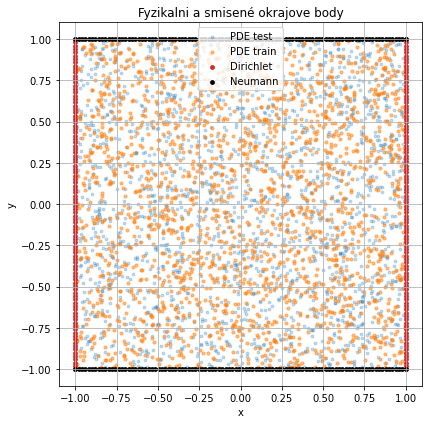

In [44]:
plot_points()


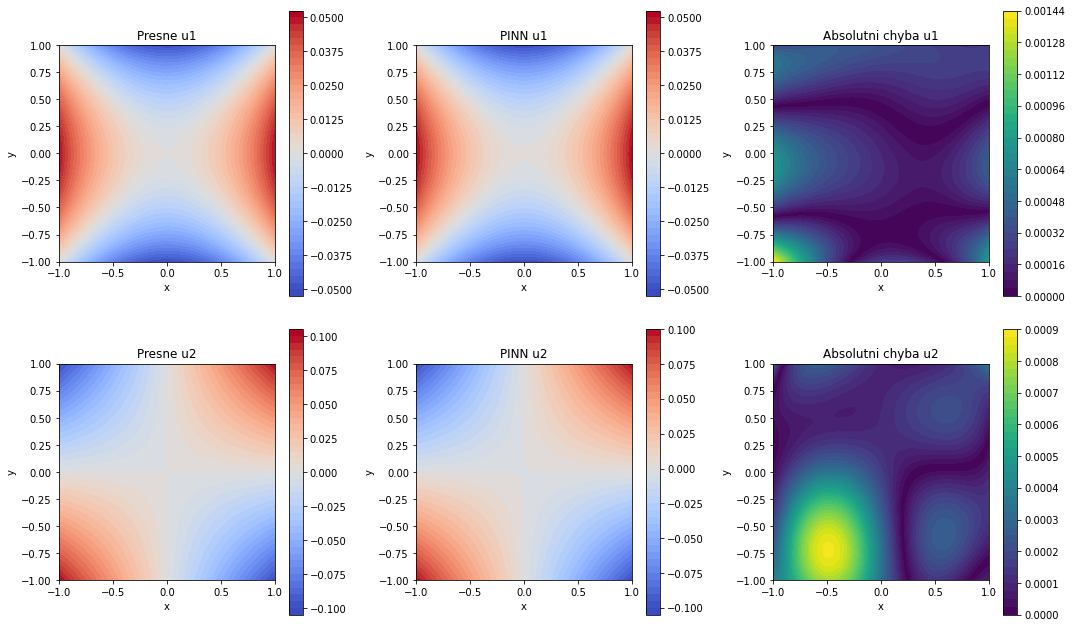

In [45]:
plot_displacement()


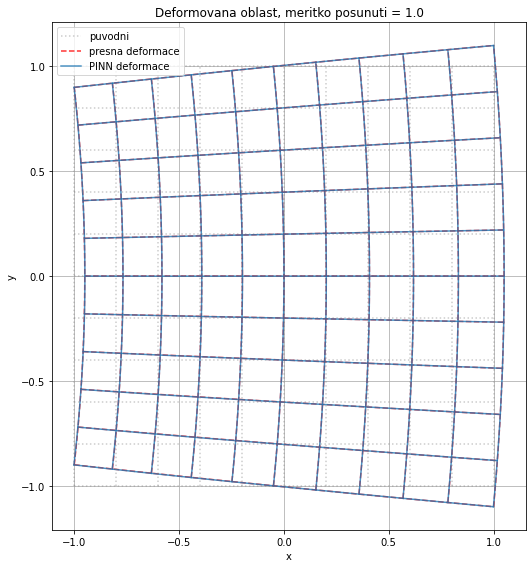

In [46]:
plot_deformed_domain(scale=1.0)


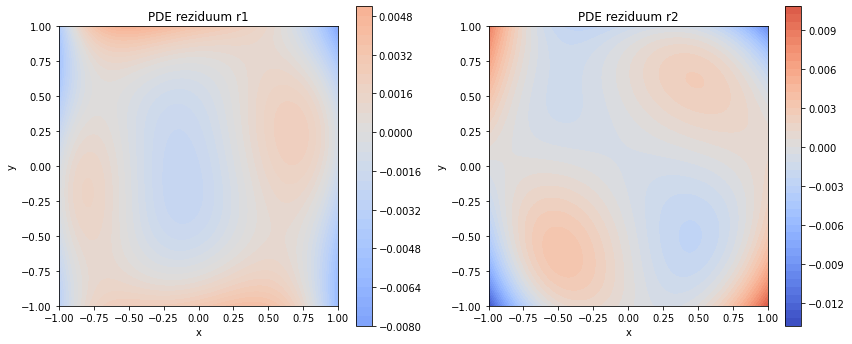

In [47]:
plot_pde_residual()


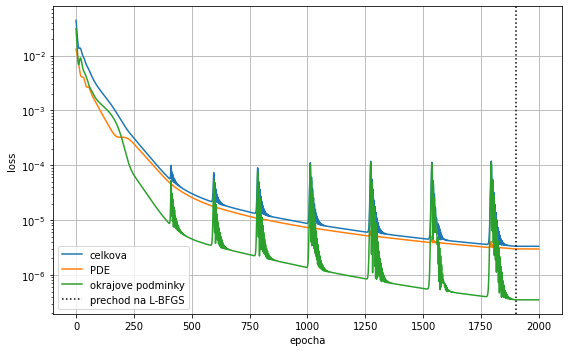

In [48]:
plot_loss()
